In [98]:
from typing import TypedDict,Annotated,List,Any
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage,AIMessage,BaseMessage,SystemMessage
from langgraph.graph import StateGraph, START,END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command,interrupt
from sentence_transformers import SentenceTransformer
import numpy as np
import uuid
from chromadb.config import Settings
import chromadb
import os
load_dotenv()

True

In [99]:
class schema(TypedDict):
    messages:Annotated[List[BaseMessage],add_messages]
'''add_messages is the reducer — tells LangGraph to append new messages
 to the list rather than replace it.
'''

'add_messages is the reducer — tells LangGraph to append new messages\n to the list rather than replace it.\n'

# Data Embeddding Manager

In [100]:
class embedding:
    def __init__(self,model_name:str="all-MiniLM-L6-v2"):
        self.model_name=model_name
        self.model=None
        self._load_model()

    def _load_model(self):
        try:
            self.model=SentenceTransformer(self.model_name)
            print(f"Model {self.model_name} loaded successfully, with dimension {self.model.get_sentence_embedding_dimension()}")
        except Exception as e:
            print(f"Error loading model: {e}")

    def generate_embedding(self,texts:List[str])->np.ndarray:
        if self.model is None:
            raise ValueError("Model is not loaded.")
        embeddings=self.model.encode(texts,show_progress_bar=True)
        print(f"Generated embeddings with shape: {embeddings.shape}")
        return embeddings
    
#initalize
embed_manager=embedding()

Model all-MiniLM-L6-v2 loaded successfully, with dimension 384


# Vector Store Manager

In [101]:
class vectorstore():
    #collection means where exactly in vector store,we store our vectors
    def __init__(self,collection_name:str="default",persist_directory:str="/Users/nisargbhatia/Desktop/langGraph/RAG/data/vectorstore"):
        self.collection_name=collection_name
        self.persist_directory=persist_directory
        self.client=None
        self.collection=None
        self._initialize_client()

    def _initialize_client(self):
        try:
            os.makedirs(self.persist_directory,exist_ok=True)
              
            self.client=chromadb.PersistentClient(path=self.persist_directory)

            self.collection=self.client.get_or_create_collection(name=self.collection_name,metadata={"description":"Vector store collection"})
            
            print(f"ChromaDB client initialized with collection: {self.collection_name}")
       

        except Exception as e:
            print(f"Error initializing ChromaDB client: {e}")

    def add_documents(self,documents:List[Any],embeddings:np.ndarray):
        if(len(documents)!=len(embeddings)):
            raise ValueError("Number of documents and embeddings must match.")
        print(f"Adding {len(documents)} documents to vector store...")
    
        ids = []
        metadatas = []
        documents_text = []
        embeddings_list = []
        
        for i, (doc, embedding) in enumerate(zip(documents, embeddings)):
            #this enumerate(zip...) fxn is used to create array of tuples(doc,embedding)
            doc_id = f"doc_{uuid.uuid4().hex[:8]}_{i}"
            ids.append(doc_id)
            metadata = dict(doc.metadata)
            metadata['doc_index'] = i
            metadata['content_length'] = len(doc.page_content)
            metadatas.append(metadata)
            documents_text.append(doc.page_content)
            embeddings_list.append(embedding.tolist())
            
        try:
            self.collection.add(
                ids=ids,
                embeddings=embeddings_list,
                metadatas=metadatas,
                documents=documents_text
            )
            '''In ChromaDB, collections.add() has these arguments, 
            id,embedding list,metadatas,documents.'''
            print(f"Successfully added {len(documents)} documents to vector store")

            
        except Exception as e:
            print(f"Error adding documents to vector store: {e}")
            raise

vec_store=vectorstore()
vec_store

ChromaDB client initialized with collection: default


# Retriever

In [102]:
class retrierver:
    def __init__(self,vectorstore:vectorstore,embedding_manager:embedding):
        self.vectorstore=vectorstore
        self.embedding_manager=embedding_manager

    def retrieve(self, query: str, top_k: int = 5, score_threshold: float = 0.0) -> List[Dict[str, Any]]:
        """
        Retrieve relevant documents for a query
        
        Args:
            query: The search query
            top_k: Number of top results to return
            score_threshold: Minimum similarity score threshold
            
        Returns:
            List of dictionaries containing retrieved documents and metadata
        """
        print(f"Retrieving documents for query: '{query}'")
        print(f"Top K: {top_k}, Score threshold: {score_threshold}")
        
        # Generate query embedding
        query_embedding = self.embedding_manager.generate_embedding([query])    
        
        # Search in vector store
        try:
            results = self.vectorstore.collection.query(
                query_embeddings=[query_embedding[0].tolist()],
                n_results=top_k
            )
            ''' THe structure of results is: 
            results= {
    'ids': [
        ['doc_a1b2c3d4_0', 'doc_e5f6g7h8_1', 'doc_i9j0k1l2_2']   # ← list of lists
    ],
    'documents': [
        ['Chunk text one...', 'Chunk text two...', 'Chunk text three...']
    ],
    'metadatas': [
        [
            {'source': 'file.pdf', 'page': 0, 'doc_index': 0, 'content_length': 843},
            {'source': 'file.pdf', 'page': 2, 'doc_index': 1, 'content_length': 912},
            {'source': 'other.pdf', 'page': 1, 'doc_index': 2, 'content_length': 756},
        ]
    ],
    'distances': [
        [0.12, 0.34, 0.51]    # cosine distances, ascending (smaller = more similar)
    ],
    'embeddings': None         # only populated if you pass include=['embeddings']
}
 '''




            # Process results
            retrieved_docs = []
            
            if results['documents'] and results['documents'][0]:
                documents = results['documents'][0]
                metadatas = results['metadatas'][0]
                distances = results['distances'][0]
                ids = results['ids'][0]
                
                for i, (doc_id, document, metadata, distance) in enumerate(zip(ids, documents, metadatas, distances)):
                    # Convert distance to similarity score (ChromaDB uses cosine distance)
                    similarity_score = 1 - distance
                    
                    if similarity_score >= score_threshold:
                        retrieved_docs.append({
                            'id': doc_id,
                            'content': document,
                            'metadata': metadata,
                            'similarity_score': similarity_score,
                            'distance': distance,
                            'rank': i + 1
                        })
                print(f"Retrieved {len(retrieved_docs)} documents (after filtering)")
                print(retrieved_docs)
            else:
                print("No documents found")
            
            return retrieved_docs
            
        except Exception as e:
            print(f"Error during retrieval: {e}")
            return []

rag_retriever=retrierver(vec_store,embed_manager)                       
        

In [103]:
llm=ChatGroq(model='llama-3.1-8b-instant')

In [104]:
@tool
def retrieve_documents(query: str) -> str:
    """Search the vector database for chunks relevant to the query.
    Use this when you need information from the software engineering documents.
    Returns relevant text chunks with source and page number."""
    print(f"Tool called with query: {query}")
    results = rag_retriever.retrieve(query, top_k=4, score_threshold=0.3)
    if not results:
        return "No relevant documents found."
    
    output = ""
    for doc in results:
        output += f"[Source: {doc['metadata'].get('source','?')}, Page: {doc['metadata'].get('page','?')}, Score: {doc['similarity_score']:.2f}]\n"
        output += doc['content'] + "\n\n"
    return output

In [105]:
tools=[retrieve_documents]
llm_with_tools=llm.bind_tools(tools)

In [106]:
def llm_node(state:schema)->schema:
    sysprompt=SystemMessage(content="""
You are an amazing assistant equipped with a tool that could make a db search for document retrieval.
                            
The DB may or may not have relevant info, so use the tool only when you think it's necessary. 
                            
If you use the tool, make sure to use the retrieved info in your next response and 
don't just rely on your own knowledge.
                            
While calling a tool, you may add more relevant words to query, don't shorten it, so that
similarity search in vector db can be more effective.      
                                           
If no useful info retrierved,provide apologies and answer the human query based on your own knowledge.
                            
If tool returns relevant info, begin your answer with "Based on retrieved documents, here's what I found: " and then provide answer based on retrieved info.
Answer:
 """)
    res=llm_with_tools.invoke([sysprompt] + state['messages'])
    return {"messages": [res]}

def where_to_go(state:schema)->str:
    last_message=state['messages'][-1]
    if last_message.tool_calls:
        return "tool_node"
    else:
        return "END"

In [107]:
graph=StateGraph(schema)
graph.add_node("llm_node",llm_node)
tool_node=ToolNode(tools)
graph.add_node("tool_node",tool_node)
graph.add_edge(START,"llm_node")
graph.add_conditional_edges("llm_node",where_to_go,
     {
    "tool_node": "tool_node",
    "END": END})
graph.add_edge("tool_node","llm_node")
app=graph.compile()

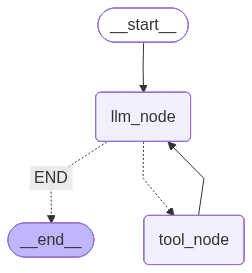

In [108]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [109]:
for res in app.stream({"messages":[HumanMessage(content="What is RUP and life of a Unified Process?")]},stream_mode="values"):
    print(res['messages'][-1].pretty_print())

================================ Human Message =================================

What is RUP and life of a Unified Process?
None
================================== Ai Message ==================================
Tool Calls:
  retrieve_documents (4an0ysd74)
 Call ID: 4an0ysd74
  Args:
    query: RUP Unified Process life cycle
None
Tool called with query: RUP Unified Process life cycle
Retrieving documents for query: 'RUP Unified Process life cycle'
Top K: 4, Score threshold: 0.3


Batches: 100%|██████████| 1/1 [00:01<00:00,  1.18s/it]


Generated embeddings with shape: (1, 384)
Retrieved 4 documents (after filtering)
[{'id': 'doc_dc9b9e46_5', 'content': '7/25/2025\n5\nLife of a Unified Process\nRUP - Summary\n•\nThe RUP is not a suitable process for all types of development but it\ndoes represent a new generation of generic processes\n•\nMost important innovation:\n•\n Combination of many views\n•\n Deployment of software is part of the process (almost ignored\nin other process models)\n•\nBased on standards\n•\n Object-oriented Modeling\n•\n Unified Modeling Language', 'metadata': {'keywords': '', 'trapped': '', 'creationdate': '2025-07-25T11:02:56+05:30', 'total_pages': 10, 'page': 4, 'title': 'Microsoft PowerPoint - IT314-Software Engineering-SPM Cont.ppt [Compatibility Mode]', 'source': '../data/pdf/IT314-Software Engineering-SPM Cont.pdf', 'modDate': "D:20250725110256+05'30'", 'doc_index': 5, 'author': 'DA-IICT', 'creator': 'PScript5.dll Version 5.2.2', 'file_path': '../data/pdf/IT314-Software Engineering-SPM Con